In [30]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from google.colab import drive
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns


In [31]:
drive.mount('/content/drive')
file_path = '/content/drive/MyDrive/Colab Notebooks/SHP/Crop_Yield_Prediction.csv'

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [32]:
df = pd.read_csv(file_path)

#  Matriks korelasi variable mana yang paling kuat

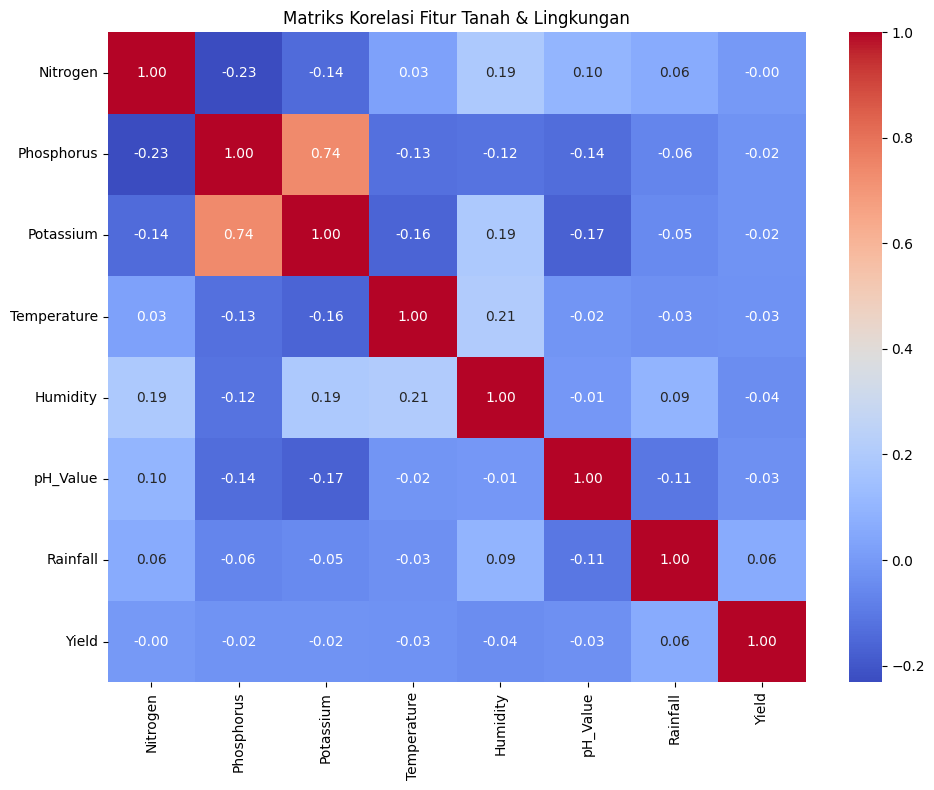

In [33]:
plt.figure(figsize=(10, 8))
correlation_matrix = df.select_dtypes(include=['float64', 'int64']).corr()
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Matriks Korelasi Fitur Tanah & Lingkungan')
plt.tight_layout()
plt.savefig('correlation_heatmap.png')

# Distribusi Yield per Crop

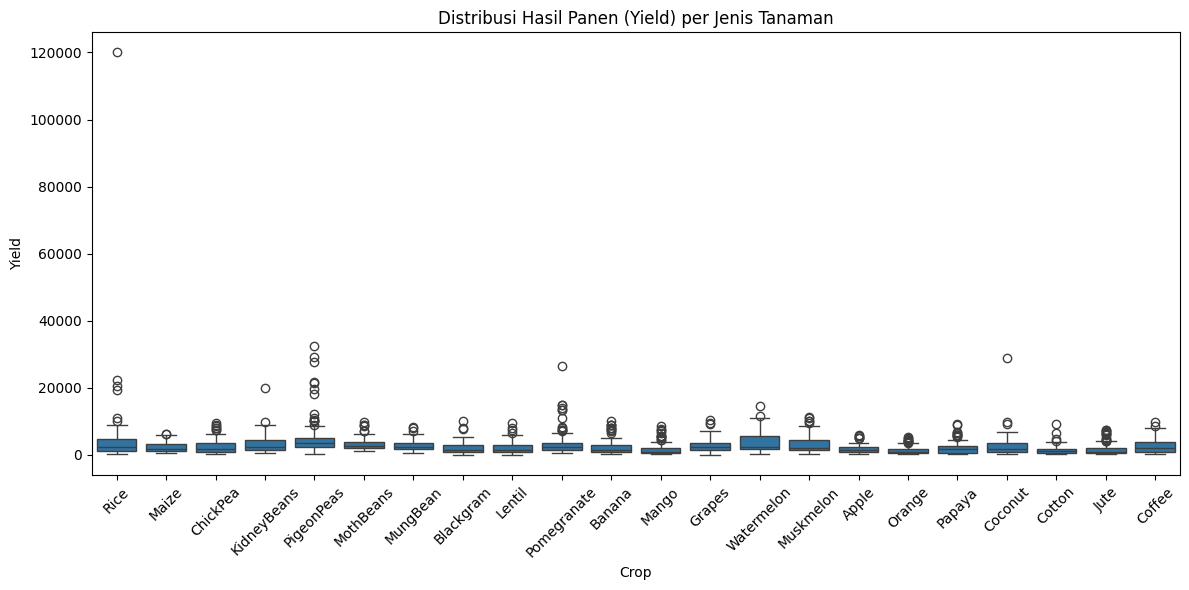

In [34]:
plt.figure(figsize=(12, 6))
sns.boxplot(x='Crop', y='Yield', data=df)
plt.title('Distribusi Hasil Panen (Yield) per Jenis Tanaman')
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig('yield_distribution_per_crop.png')

In [35]:
# Menghitung jumlah kemunculan setiap kelas tanaman
distribusi_kelas = df['Crop'].value_counts()
print(distribusi_kelas)

Crop
Rice           100
Maize          100
ChickPea       100
KidneyBeans    100
PigeonPeas     100
MothBeans      100
MungBean       100
Blackgram      100
Lentil         100
Pomegranate    100
Banana         100
Mango          100
Grapes         100
Watermelon     100
Muskmelon      100
Apple          100
Orange         100
Papaya         100
Coconut        100
Cotton         100
Jute           100
Coffee         100
Name: count, dtype: int64


# Scatter Plot

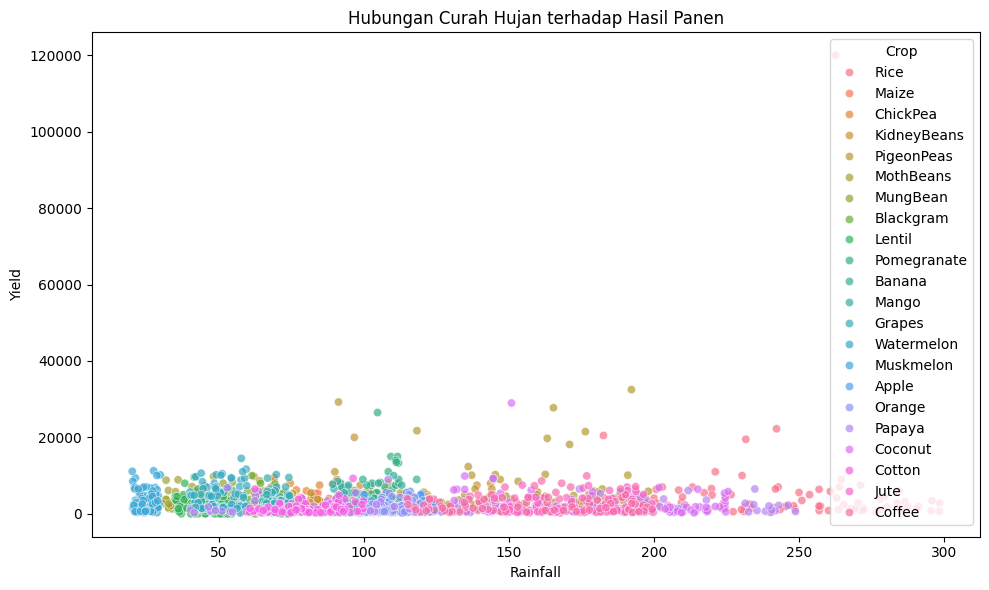

In [36]:
plt.figure(figsize=(10, 6))
sns.scatterplot(x='Rainfall', y='Yield', hue='Crop', data=df, alpha=0.7)
plt.title('Hubungan Curah Hujan terhadap Hasil Panen')
plt.tight_layout()
plt.savefig('rainfall_vs_yield.png')

# Distrbusi Unsur Hara

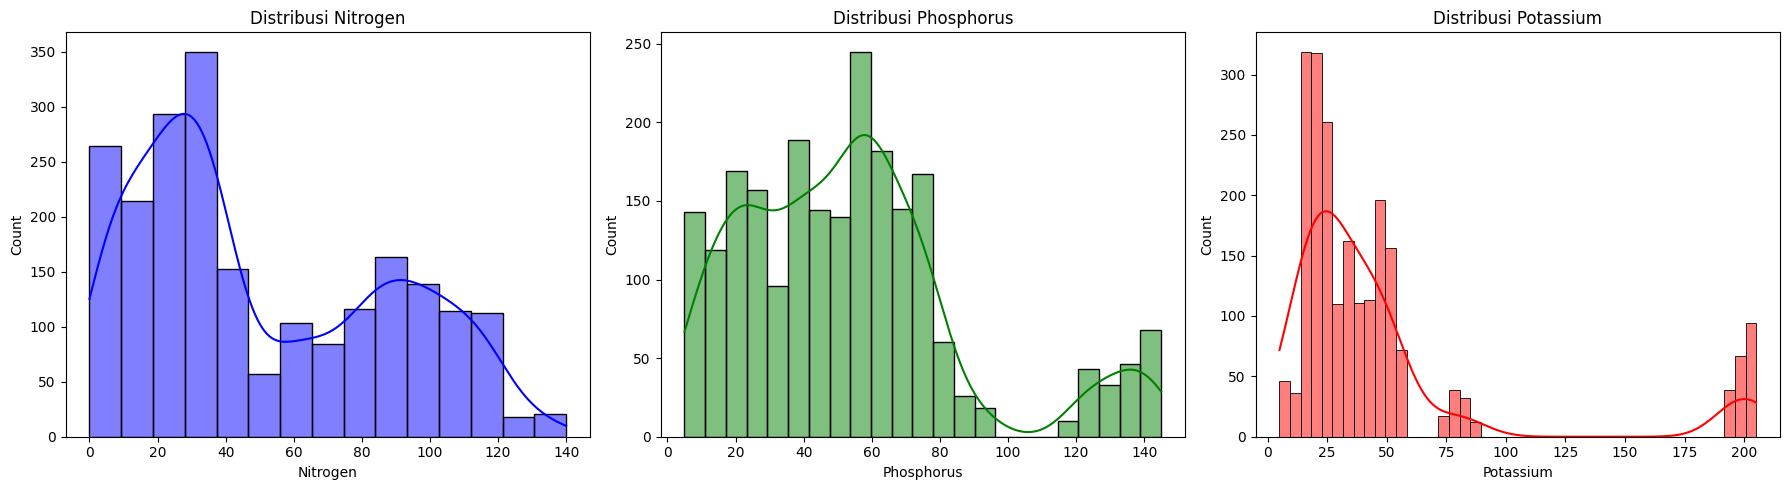

In [37]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
sns.histplot(df['Nitrogen'], kde=True, ax=axes[0], color='blue').set_title('Distribusi Nitrogen')
sns.histplot(df['Phosphorus'], kde=True, ax=axes[1], color='green').set_title('Distribusi Phosphorus')
sns.histplot(df['Potassium'], kde=True, ax=axes[2], color='red').set_title('Distribusi Potassium')
plt.tight_layout()
plt.savefig('nutrients_distribution.png')

# EDA

missing values

In [38]:
missing_values = df.isnull().sum()
print(missing_values)

Nitrogen       0
Phosphorus     0
Potassium      0
Temperature    0
Humidity       0
pH_Value       0
Rainfall       0
Crop           0
Yield          0
dtype: int64


duplikat

In [39]:
duplicates_count = df.duplicated().sum()
print(duplicates_count)

0


check outlier

In [40]:
q1 = df['Yield'].quantile(0.25)
q3 = df['Yield'].quantile(0.75)
iqr = q3 - q1
lower_bound = q1 - 1.5 * iqr
upper_bound = q3 + 1.5 * iqr

In [41]:
outliers = df[(df['Yield'] < lower_bound) | (df['Yield'] > upper_bound)]

print(f"\n[3] Analisis Outlier (Kolom Yield):")
print(f"   - Batas Bawah (Lower Bound): {lower_bound}")
print(f"   - Batas Atas (Upper Bound): {upper_bound}")
print(f"   - Jumlah Outlier Terdeteksi: {len(outliers)}")
print("\n5 Data Outlier Teratas:")
print(outliers.head())


[3] Analisis Outlier (Kolom Yield):
   - Batas Bawah (Lower Bound): -2875.0
   - Batas Atas (Upper Bound): 7325.0
   - Jumlah Outlier Terdeteksi: 107

5 Data Outlier Teratas:
    Nitrogen  Phosphorus  Potassium  Temperature   Humidity  pH_Value  \
4         78          42         42    20.130175  81.604873  7.628473   
6         69          55         38    22.708838  82.639414  5.700806   
8         89          54         38    24.515881  83.535216  6.685346   
9         68          58         38    23.223974  83.033227  6.336254   
10        91          53         40    26.527235  81.417538  5.386168   

      Rainfall  Crop   Yield  
4   262.717340  Rice  120000  
6   271.324860  Rice    7500  
8   230.446236  Rice   10000  
9   221.209196  Rice   11000  
10  264.614870  Rice    9000  


In [42]:
df_clean = df[(df['Yield'] >= lower_bound) & (df['Yield']<=upper_bound)].copy()
print(f"Jumlah data sebelum cleaning: {len(df)}")
print(f"Jumlah data setelah cleaning outlier: {len(df_clean)}")

Jumlah data sebelum cleaning: 2200
Jumlah data setelah cleaning outlier: 2093


splitting

In [43]:
X = df[['Nitrogen', 'Phosphorus', 'Potassium', 'Temperature', 'Humidity', 'pH_Value', 'Rainfall']]
y = df['Crop']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"\nDimensi X_train (Pelatihan): {X_train.shape}")
print(f"Dimensi X_test (Pengujian): {X_test.shape}")


Dimensi X_train (Pelatihan): (1760, 7)
Dimensi X_test (Pengujian): (440, 7)


PIPELINE PREPROCESSING DATA

In [44]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [45]:
model_rf_class = RandomForestClassifier(n_estimators=100, random_state=42)
model_rf_class.fit(X_train_scaled, y_train)

RandomForestClassifier(random_state=42)

In [46]:
model_lr = LogisticRegression(max_iter=500, random_state=42)

# Kandidat 2: Random Forest Classifier (Ensemble - Bagging)
# Menggunakan 100 pohon keputusan untuk melakukan voting kelas tanaman
model_rf = RandomForestClassifier(n_estimators=100, random_state=42)

# Kandidat 3: Gradient Boosting Classifier (Ensemble - Boosting)
# Membangun pohon keputusan secara sekuensial untuk mengoreksi error prediktor sebelumnya
model_gb = GradientBoostingClassifier(n_estimators=100, learning_rate=0.1, random_state=42)

In [47]:
print("--- MEMULAI PROSES PELATIHAN MODEL KLASIFIKASI ---")

print("Melatih Model 1: Logistic Regression...")
model_lr.fit(X_train_scaled, y_train)

print("Melatih Model 2: Random Forest Classifier...")
model_rf.fit(X_train_scaled, y_train)

print("Melatih Model 3: Gradient Boosting Classifier...")
model_gb.fit(X_train_scaled, y_train)

print("Semua model kandidat klasifikasi berhasil dilatih.\n")

--- MEMULAI PROSES PELATIHAN MODEL KLASIFIKASI ---
Melatih Model 1: Logistic Regression...
Melatih Model 2: Random Forest Classifier...
Melatih Model 3: Gradient Boosting Classifier...
Semua model kandidat klasifikasi berhasil dilatih.



In [48]:
y_pred_lr = model_lr.predict(X_test_scaled)
y_pred_rf = model_rf.predict(X_test_scaled)
y_pred_gb = model_gb.predict(X_test_scaled)

print("Proses prediksi pada data uji selesai. Data siap dievaluasi pada Fase 3.")

Proses prediksi pada data uji selesai. Data siap dievaluasi pada Fase 3.


In [49]:
acc_lr = accuracy_score(y_test, y_pred_lr)
acc_rf = accuracy_score(y_test, y_pred_rf)
acc_gb = accuracy_score(y_test, y_pred_gb)

In [50]:
ringkasan_akurasi = pd.DataFrame({
    'Model Kandidat Klasifikasi': ['Logistic Regression (Baseline)', 'Random Forest Classifier', 'Gradient Boosting Classifier'],
    'Akurasi Pengujian': [f"{acc_lr*100:.2f}%", f"{acc_rf*100:.2f}%", f"{acc_gb*100:.2f}%"]
})

In [51]:
print("--- PERBANDINGAN AKURASI GLOBAL MODEL ---")
print(ringkasan_akurasi.to_string(index=False))
print("\n" + "="*60 + "\n")

--- PERBANDINGAN AKURASI GLOBAL MODEL ---
    Model Kandidat Klasifikasi Akurasi Pengujian
Logistic Regression (Baseline)            96.36%
      Random Forest Classifier            99.32%
  Gradient Boosting Classifier            98.18%




In [52]:
print("--- LAPORAN KLASIFIKASI DETAIL (RANDOM FOREST) ---")
print(classification_report(y_test, y_pred_rf))
print("="*60 + "\n")

--- LAPORAN KLASIFIKASI DETAIL (RANDOM FOREST) ---
              precision    recall  f1-score   support

       Apple       1.00      1.00      1.00        23
      Banana       1.00      1.00      1.00        21
   Blackgram       1.00      1.00      1.00        20
    ChickPea       1.00      1.00      1.00        26
     Coconut       1.00      1.00      1.00        27
      Coffee       1.00      1.00      1.00        17
      Cotton       1.00      1.00      1.00        17
      Grapes       1.00      1.00      1.00        14
        Jute       0.92      1.00      0.96        23
 KidneyBeans       1.00      1.00      1.00        20
      Lentil       0.92      1.00      0.96        11
       Maize       1.00      1.00      1.00        21
       Mango       1.00      1.00      1.00        19
   MothBeans       1.00      0.96      0.98        24
    MungBean       1.00      1.00      1.00        19
   Muskmelon       1.00      1.00      1.00        17
      Orange       1.00      1

In [53]:
# Membuat matriks untuk melihat distribusi salah tebak antar jenis tanaman
cm = confusion_matrix(y_test, y_pred_rf)
plt.figure(figsize=(14, 10))

<Figure size 1400x1000 with 0 Axes>

<Figure size 1400x1000 with 0 Axes>

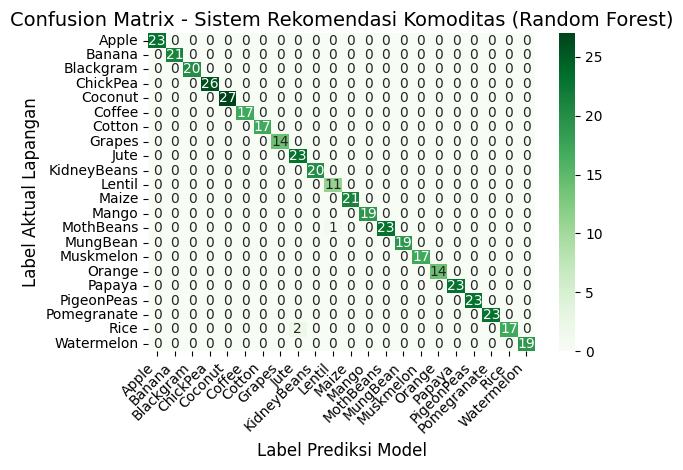

In [54]:
# Menggunakan nama-nama kelas tanaman unik sebagai label sumbu
label_tanaman = sorted(y_test.unique())
sns.heatmap(cm, annot=True, fmt='d', cmap='Greens',
            xticklabels=label_tanaman, yticklabels=label_tanaman)

plt.title('Confusion Matrix - Sistem Rekomendasi Komoditas (Random Forest)', fontsize=14)
plt.xlabel('Label Prediksi Model', fontsize=12)
plt.ylabel('Label Aktual Lapangan', fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()

Random Forest Classifier Tuning

In [55]:
from sklearn.model_selection import RandomizedSearchCV

rf_model = RandomForestClassifier(random_state=42)

# Parameter tuning
rf_param_dist = {
    'n_estimators': [50, 100, 200, 300],
    'max_depth': [None, 10, 20, 30],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4]
}

# random search
rf_random_search = RandomizedSearchCV(
    estimator=rf_model,
    param_distributions=rf_param_dist,
    n_iter=10,              # jumlah kombinasi yang dicoba
    cv=5,
    scoring='accuracy',
    random_state=42,
    n_jobs=-1,
    verbose=2
)

# Training
rf_random_search.fit(X_train, y_train)

# Model terbaik
best_rf_model = rf_random_search.best_estimator_

print("Best Parameter Random Forest:")
print(rf_random_search.best_params_)


Fitting 5 folds for each of 10 candidates, totalling 50 fits
Best Parameter Random Forest:
{'n_estimators': 100, 'min_samples_split': 10, 'min_samples_leaf': 1, 'max_depth': 30}


In [56]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix
)

y_pred_rf = best_rf_model.predict(X_test)

accuracy_rf = accuracy_score(y_test, y_pred_rf)
precision_rf = precision_score(y_test, y_pred_rf, average='weighted')
recall_rf = recall_score(y_test, y_pred_rf, average='weighted')
f1_rf = f1_score(y_test, y_pred_rf, average='weighted')

print("\n=== RANDOM FOREST EVALUATION ===")
print("Accuracy :", accuracy_rf)
print("Precision:", precision_rf)
print("Recall   :", recall_rf)
print("F1-Score :", f1_rf)

print("\nClassification Report:")
print(classification_report(y_test, y_pred_rf))



=== RANDOM FOREST EVALUATION ===
Accuracy : 0.9954545454545455
Precision: 0.9958181818181817
Recall   : 0.9954545454545455
F1-Score : 0.9954229797979799

Classification Report:
              precision    recall  f1-score   support

       Apple       1.00      1.00      1.00        23
      Banana       1.00      1.00      1.00        21
   Blackgram       1.00      1.00      1.00        20
    ChickPea       1.00      1.00      1.00        26
     Coconut       1.00      1.00      1.00        27
      Coffee       1.00      1.00      1.00        17
      Cotton       1.00      1.00      1.00        17
      Grapes       1.00      1.00      1.00        14
        Jute       0.92      1.00      0.96        23
 KidneyBeans       1.00      1.00      1.00        20
      Lentil       1.00      1.00      1.00        11
       Maize       1.00      1.00      1.00        21
       Mango       1.00      1.00      1.00        19
   MothBeans       1.00      1.00      1.00        24
    MungBea

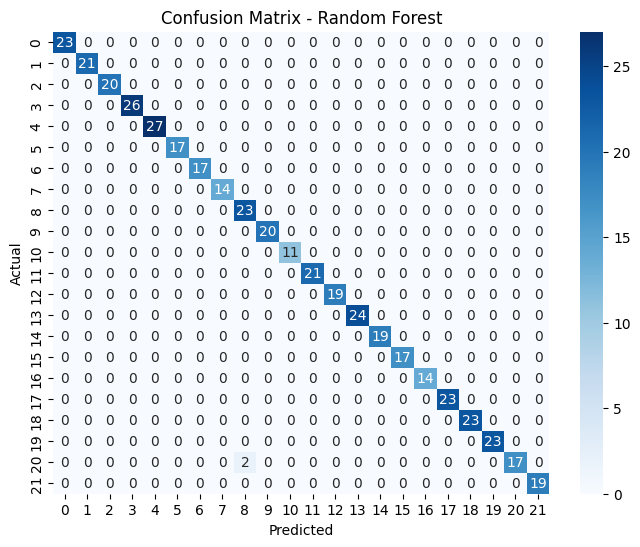

In [57]:
cm_rf = confusion_matrix(y_test, y_pred_rf)

plt.figure(figsize=(8,6))
sns.heatmap(cm_rf, annot=True, fmt='d', cmap='Blues')
plt.title("Confusion Matrix - Random Forest")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

Random Forest Saving

In [58]:
import joblib

joblib.dump(best_rf_model, 'best_random_forest.pkl')

# Simpan scaler (WAJIB jika menggunakan scaling)
joblib.dump(scaler, 'scaler.pkl')

print("\nModel Random Forest dan scaler berhasil disimpan.")


Model Random Forest dan scaler berhasil disimpan.
